In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

import sklearn
sklearn.set_config(display="text")

In [2]:
base_path = r"C:\kdt_0900_hhj\ml\resource\dataset"
file_name = r"fish.csv"
file_path = os.path.join(base_path,file_name)
file_path

'C:\\kdt_0900_hhj\\ml\\resource\\dataset\\fish.csv'

In [3]:
df = pd.read_csv(file_path)
df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [4]:
df["Species"].unique()

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

### fish 종류
    Bream: 도미류
    Roach: 잉어과 담수어
    Whitefish: 송어
    Parkki: 청돔
    Perch: 농어
    Pike: 강꼬치고기
    Smelt: 빙어

### fish 컬럼 설명
| 컬럼명 (Column) | 설명 (Description) | 단위 (Unit) |
| :--- | :--- | :--- |
| **Species** | 물고기의 종류 (예: Bream, Smelt 등) | 분류 (텍스트) |
| **Weight** | 물고기의 무게 | 그램 (g) |
| **Length** | 물고기의 길이 | 센티미터 (cm) |
| **Diagonal** | 물고기의 대각선 길이 | 센티미터 (cm) |
| **Height** | 물고기의 최대 높이 | 센티미터 (cm) |
| **Width** | 물고기의 최대 너비 | 센티미터 (cm) |

In [5]:
df["Species"].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [7]:
df.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


## 분류 문제 지도학습 목표
- 생선의 길이와 무게 만으로 생선의 종류를 분류
- 도미, 빙어

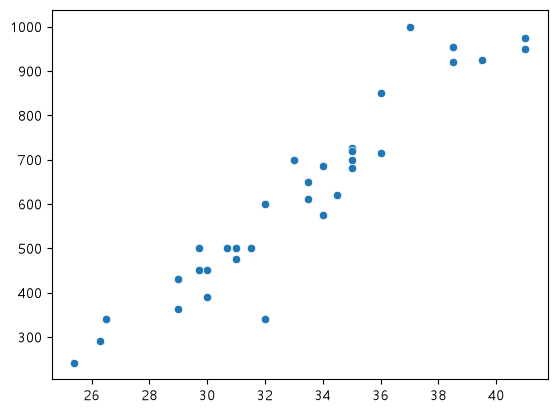

In [8]:
bream_length = list(df[df["Species"] == "Bream"]["Length"])
bream_weight = list(df[df["Species"] == "Bream"]["Weight"])

# print(bream_length)
# print(bream_weight)

sns.scatterplot(x=bream_length, y=bream_weight)
plt.show()

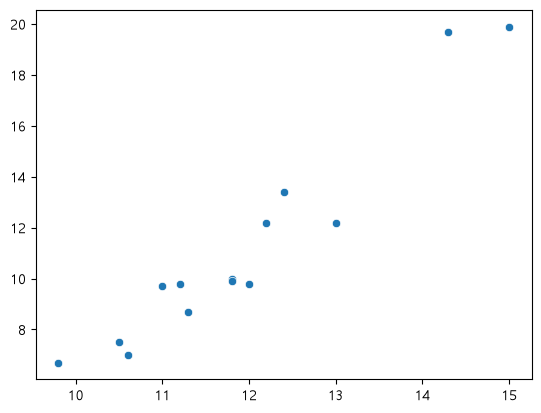

In [9]:
smelt_length = list(df[df["Species"] == "Smelt"]["Length"])
smelt_weight = list(df[df["Species"] == "Smelt"]["Weight"])

sns.scatterplot(x=smelt_length, y=smelt_weight)
plt.show()

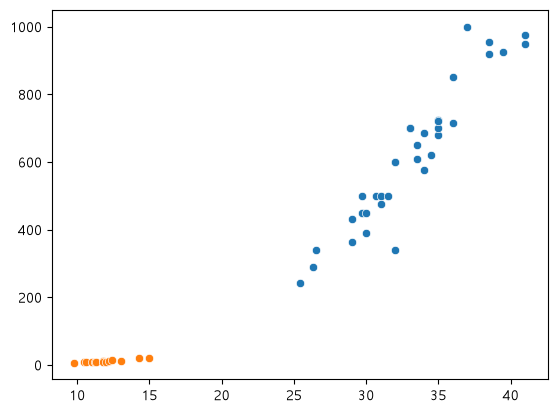

In [10]:
sns.scatterplot(x=bream_length, y=bream_weight)
sns.scatterplot(x=smelt_length, y=smelt_weight)

plt.show()

In [11]:
fish_df = df[df["Species"].isin(["Bream","Smelt"])]
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
5,Bream,450.0,29.7,34.7,13.6024,4.9274
6,Bream,500.0,29.7,34.5,14.1795,5.2785
7,Bream,390.0,30.0,35.0,12.6700,4.6900
8,Bream,450.0,30.0,35.1,14.0049,4.8438
9,Bream,500.0,30.7,36.2,14.2266,4.9594


## 분류형 데이터 인코딩

In [12]:
# fish_df["Species"].map(lambda specie: {"Bream": 0, "Smelt": 1}[specie])
    
#참조형
# 받자마자 딕셔너리로 바꾸기? 먼소리지 ㅠㅠ
fish_df["Species"] = fish_df["Species"].map({"Bream": 0, "Smelt": 1})

In [13]:
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340


## 1단계, 데이터 준비(탐색)

In [14]:
fish_df.info()

<class 'pandas.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     int64  
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 2.7 KB


In [15]:
#이상치 확인
fish_df.describe()

,Species,Weight,Length,Diagonal,Height,Width
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.285714,444.500000,27.055102,31.120408,11.476400,4.259751
std,0.456435,328.143233,10.242804,12.097296,6.150976,1.967686
min,0.000000,6.700000,9.800000,10.800000,1.728400,1.047600
25%,0.000000,19.700000,14.300000,15.200000,2.872800,1.879200
50%,0.000000,500.000000,31.000000,36.200000,14.179500,5.072800
75%,1.000000,700.000000,34.500000,39.700000,15.633000,5.589000
max,1.000000,1000.000000,41.000000,46.500000,18.957000,6.749700


In [16]:
fish_df = fish_df.drop(["Diagonal","Height","Width"], axis=1)
fish_df.head()

,Species,Weight,Length
0,0,242.0,25.4
1,0,290.0,26.3
2,0,340.0,26.5
3,0,363.0,29.0
4,0,430.0,29.0


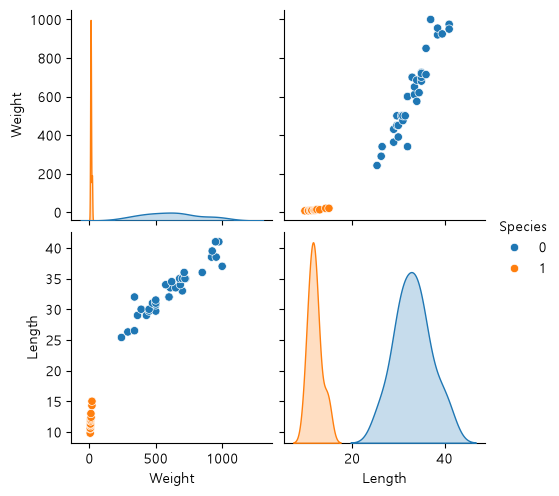

In [17]:
sns.pairplot(fish_df, hue="Species")
plt.show()

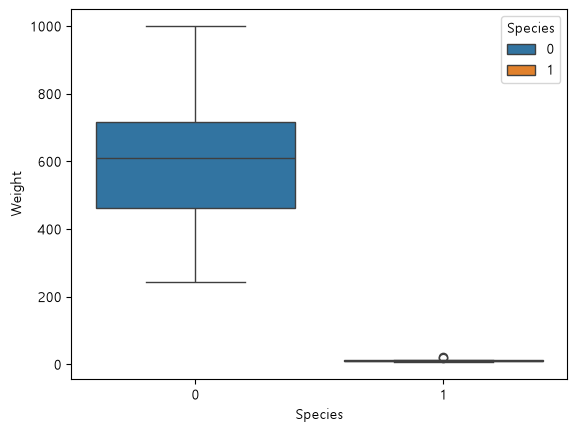

In [18]:
sns.boxplot(fish_df,x="Species",y="Weight", hue="Species")
plt.show()

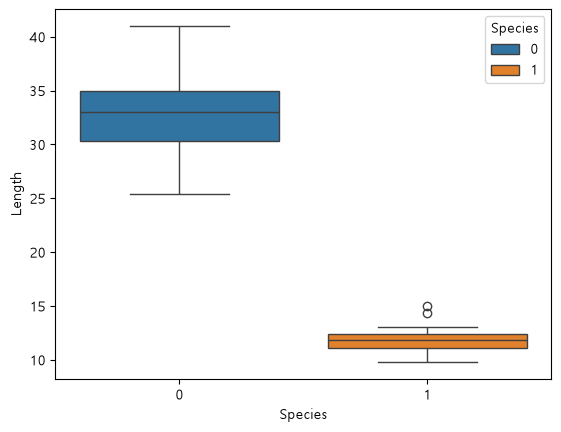

In [19]:
sns.boxplot(fish_df,x="Species",y="Length", hue="Species")
plt.show()

In [1]:
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Weight", ax=axes[0])
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Length", ax=axes[1])
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Weight", ax=axes[2], color="orange")
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Length", ax=axes[3], color="orange")
plt.show()

NameError: name 'plt' is not defined

## 2단계, 데이터 분할

In [21]:
# 독립변수, 종속변수
fish_df.head()

X = fish_df.drop("Species", axis=1)
X.head()

,Weight,Length
0,242.0,25.4
1,290.0,26.3
2,340.0,26.5
3,363.0,29.0
4,430.0,29.0


In [22]:
y = fish_df["Species"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(39, 2) (10, 2) (39,) (10,)


## 3단계, 모델 준비

## KNN(k-최근접 이웃, k-neighbors) 알고리즘
- 어떤 데이터에 대한 답을 구할 때 주변의 다른 데이터를 보고 다수를 차지하는 데이터를 정답으로 결정하는 방식의 알고리즘

## KNN 장점
- 데이터만 있으면 알고리즘을 사용할 수 있다.

## KNN 단점
- 데이터가 많으면 사용하기 힘들며, 많은 메모리를 사용한다.

In [24]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

## 4단계, 모델 학습

In [25]:
# 표준화가 안된 쓰레기 데이터
kn.fit(X_train, y_train)

KNeighborsClassifier()

## 5단계, 모델 예측

In [26]:
y_pred = kn.predict(X_test)
print(y_pred)
print(list(y_test))

[0 0 1 0 0 0 1 1 1 1]
[0, 0, 1, 0, 0, 0, 1, 1, 1, 1]


## 6단계, 모델평가

In [27]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [28]:
# print(f"accuracy_score: {kn.score(X_train, y_train)}")
print(f"accuracy_score: {accuracy_score(y_test, y_pred)}")

accuracy_score: 1.0


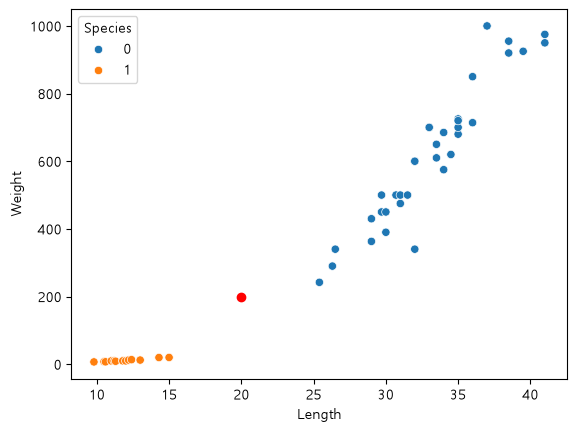

In [29]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color="red")
plt.show()

In [30]:
columns = X_train.columns
new_data = pd.DataFrame([[20,200]], columns=columns)
new_data

,Weight,Length
0,20,200


In [31]:
kn.predict(new_data)

array([1])

In [32]:
distance, indexes = kn.kneighbors(new_data)
print(distance, indexes)

[[185.00002703 185.70024233 187.71606218 187.96191104 188.46548756]] [[19 17 34 27  2]]


In [33]:
# 이웃의 값
neighbors = X_train.iloc[indexes[0]]
neighbors

,Weight,Length
158,19.9,15.0
157,19.7,14.3
155,13.4,12.4
154,12.2,12.2
151,10.0,11.8


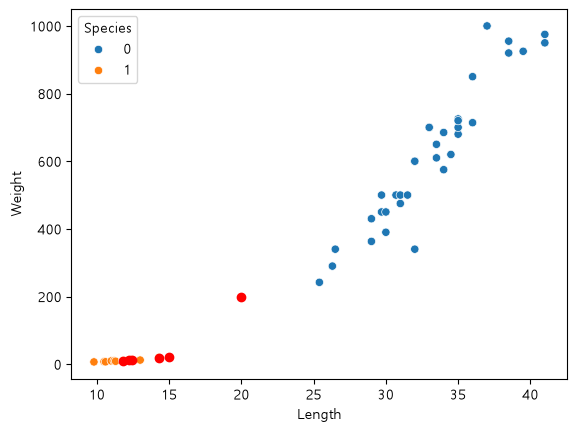

In [34]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color="red")
plt.scatter(neighbors["Length"],neighbors["Weight"], color="red")
plt.show()

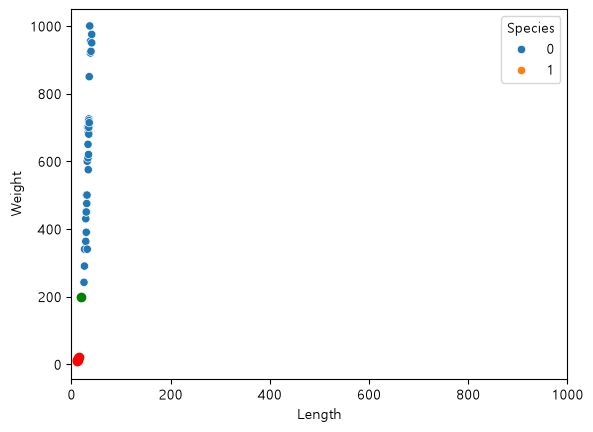

In [35]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color="green")
plt.scatter(neighbors["Length"],neighbors["Weight"], color="red")
plt.xlim(0,1000)
plt.show()

In [40]:
# StandardScaler 표준화
from sklearn.preprocessing import StandardScaler

# (데이터 값 - 평균) / 표준 편차
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# (데이터 값 - 평균) / 표준 편차
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
print(mean)
print(std)

Weight    476.233333
Length     28.187179
dtype: float64
Weight    314.032187
Length      9.464378
dtype: float64


In [50]:
X_train_scaled_df = (X_train - mean) / std
X_train_scaled_df["Species"] = y_train
X_train_scaled_df.head()

,Weight,Length,Species
3,-0.360579,0.085882,0
0,-0.745890,-0.294492,0
151,-1.484667,-1.731459,1
8,-0.083537,0.191541,0
22,0.457809,0.667008,0


In [56]:
new_data_scaled = (new_data - mean) / std
#표준화가 된 값
new_data_scaled

,Weight,Length
0,-1.452823,18.15363


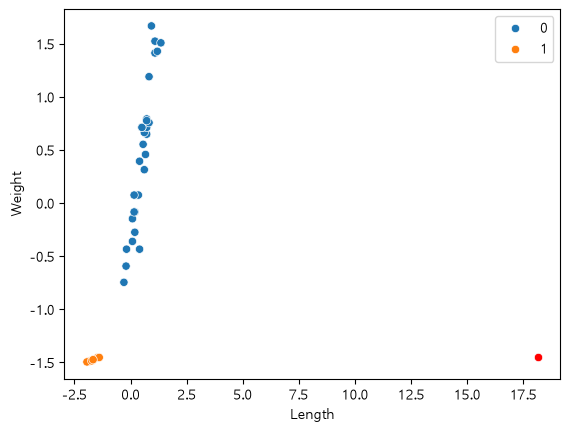

In [58]:
sns.scatterplot(X_train_scaled_df, x="Length", y="Weight", hue="Species")
sns.scatterplot(new_data_scaled, x="Length", y="Weight", color="red")
plt.show()

## 사이킷런 모델학습 사이클

In [59]:
kn = KNeighborsClassifier()

In [60]:
kn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
#모델예측
y_pred = kn.predict(X_test_scaled)
y_pred

In [ ]:
#모델평가
accuracy_score(y_pred, y_test)

In [61]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[5, 0],
       [0, 5]])

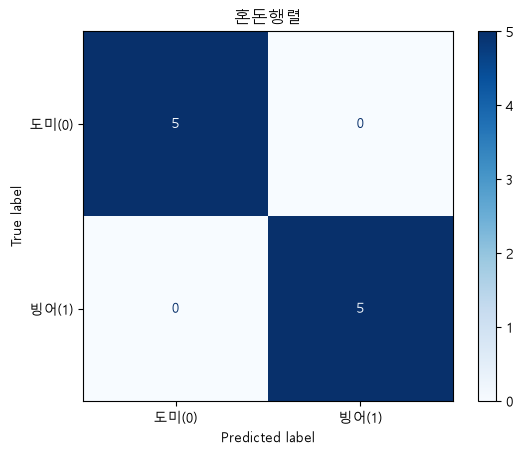

In [63]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["도미(0)", "빙어(1)"])
display.plot(cmap="Blues")
plt.title("혼돈행렬")
plt.show()